# Notebook 3: Collaborative Filtering (Baseline 2)
Χρησιμοποιούμε **SVD (Matrix Factorization)** μέσω της `scikit-surprise` library.

In [1]:
import pandas as pd
import numpy as np
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

## 1. Φόρτωση Δεδομένων

In [2]:
train  = pd.read_csv('../data/train.csv')
test   = pd.read_csv('../data/test.csv')
movies = pd.read_csv('../data/movies.csv')

print('Train:', train.shape, '| Test:', test.shape)

Train: (800167, 4) | Test: (200042, 4)


## 2. Προετοιμασία για Surprise
Η `surprise` library χρειάζεται τα δεδομένα σε δικό της format.

In [3]:
reader = Reader(rating_scale=(1, 5))

# Full dataset για cross-validation
full_data = Dataset.load_from_df(
    train[['user_id','item_id','rating']], reader
)

# Trainset από το train CSV
trainset = full_data.build_full_trainset()

print('Surprise trainset έτοιμο.')

Surprise trainset έτοιμο.


## 3. SVD Εκπαίδευση
SVD με **100 latent factors**, learning rate 0.005, regularization 0.02.

In [4]:
svd = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)

print('Εκπαίδευση SVD (3-fold CV για αξιολόγηση)...')
cv_results = cross_validate(svd, full_data, measures=['RMSE','MAE'], cv=3, verbose=False)

print(f'CV RMSE: {cv_results["test_rmse"].mean():.4f} ± {cv_results["test_rmse"].std():.4f}')
print(f'CV MAE:  {cv_results["test_mae"].mean():.4f} ± {cv_results["test_mae"].std():.4f}')

Εκπαίδευση SVD (3-fold CV για αξιολόγηση)...


CV RMSE: 0.8980 ± 0.0011
CV MAE:  0.7071 ± 0.0006


## 4. Εκπαίδευση στο πλήρες train set & αξιολόγηση στο test

In [5]:
print('Εκπαίδευση SVD στο πλήρες train set...')
svd.fit(trainset)

# Predictions στο test set
test = test.copy()
test['cf_pred'] = test.apply(
    lambda row: svd.predict(row['user_id'], row['item_id']).est, axis=1
)
test['cf_pred'] = test['cf_pred'].clip(1, 5)

rmse_cf = np.sqrt(((test['rating'] - test['cf_pred'])**2).mean())
mae_cf  = (test['rating'] - test['cf_pred']).abs().mean()

print(f'\nCollaborative Filtering (SVD) — Test set:')
print(f'  RMSE: {rmse_cf:.4f}')
print(f'  MAE:  {mae_cf:.4f}')

Εκπαίδευση SVD στο πλήρες train set...



Collaborative Filtering (SVD) — Test set:
  RMSE: 0.8784
  MAE:  0.6902


## 5. Precision@K, Recall@K, F1@K

In [6]:
def precision_recall_f1_at_k(test_df, pred_col, k=10, threshold=4.0):
    precisions, recalls = [], []
    for user_id, group in test_df.groupby('user_id'):
        top_k    = set(group.nlargest(k, pred_col)['item_id'].tolist())
        relevant = set(group[group['rating'] >= threshold]['item_id'].tolist())
        if not relevant:
            continue
        hits = len(top_k & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
    p  = np.mean(precisions)
    r  = np.mean(recalls)
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0
    return p, r, f1

results_cf = {}
for k in [5, 10]:
    p, r, f1 = precision_recall_f1_at_k(test, 'cf_pred', k=k)
    results_cf[k] = {'Precision': p, 'Recall': r, 'F1': f1}
    print(f'K={k:2d}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}')

K= 5  Precision=0.7917  Recall=0.4404  F1=0.5660


K=10  Precision=0.6866  Recall=0.6387  F1=0.6618


## 6. Σύγκριση CB vs CF (μέχρι τώρα)

              Model     RMSE      MAE  Precision@10  Recall@10    F1@10
      Content-Based 1.016183 0.811930      0.607191   0.595650 0.601365
Collaborative (SVD) 0.878385 0.690212      0.686620   0.638748 0.661819


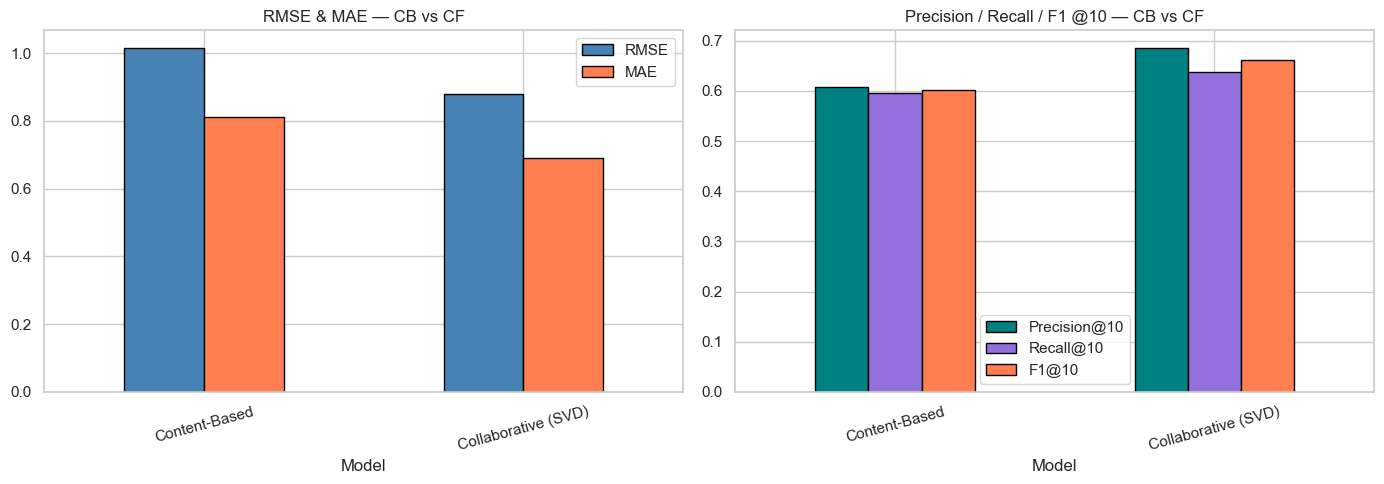

In [7]:
with open('../results/cb_results.json') as f:
    cb_res = json.load(f)

comparison = pd.DataFrame({
    'Model':         ['Content-Based', 'Collaborative (SVD)'],
    'RMSE':          [cb_res['rmse'], rmse_cf],
    'MAE':           [cb_res['mae'], mae_cf],
    'Precision@10':  [cb_res['precision_recall_f1']['10']['Precision'], results_cf[10]['Precision']],
    'Recall@10':     [cb_res['precision_recall_f1']['10']['Recall'],    results_cf[10]['Recall']],
    'F1@10':         [cb_res['precision_recall_f1']['10']['F1'],        results_cf[10]['F1']],
})

print(comparison.to_string(index=False))

# Bar chart σύγκρισης
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison.set_index('Model')[['RMSE','MAE']].plot(
    kind='bar', ax=axes[0], color=['steelblue','coral'], edgecolor='black'
)
axes[0].set_title('RMSE & MAE — CB vs CF')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()

comparison.set_index('Model')[['Precision@10','Recall@10','F1@10']].plot(
    kind='bar', ax=axes[1], color=['teal','mediumpurple','coral'], edgecolor='black'
)
axes[1].set_title('Precision / Recall / F1 @10 — CB vs CF')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../results/05_cb_vs_cf.png', dpi=150)
plt.show()

## 7. Αποθήκευση Μοντέλου & Predictions

In [8]:
# Αποθήκευση trained SVD model
with open('../data/svd_model.pkl', 'wb') as f:
    pickle.dump(svd, f)

# Αποθήκευση CF predictions για χρήση στο hybrid
test[['user_id','item_id','rating','cf_pred']].to_csv('../data/test_cf_preds.csv', index=False)

cf_results = {'rmse': rmse_cf, 'mae': mae_cf, 'precision_recall_f1': results_cf}
with open('../results/cf_results.json', 'w') as f:
    json.dump(cf_results, f, indent=2)

print('Model & αποτελέσματα αποθηκεύτηκαν.')

Model & αποτελέσματα αποθηκεύτηκαν.
